In [1]:
# Cell 1: fetch latest runs per (dataset_id, p_uniform, seed)
import ast
import json

import numpy as np
import pandas as pd
import wandb


def _cfg_get(cfg, path, default=np.nan):
    # handle both nested {'algo': {'p_uniform': ...}} and flat {'algo.p_uniform': ...}
    if isinstance(cfg, dict) and path in cfg:
        return cfg[path]

    cur = cfg
    for part in path.split("."):
        if not isinstance(cur, dict) or part not in cur:
            return default
        cur = cur[part]
    return cur


def _cfg_from_api_run(api, run_stub):
    # force full run object; api.runs(...) entries can be partial stubs
    run = api.run("/".join(run_stub.path))

    direct = dict(run.config or {})
    if direct:
        return run, direct

    raw = json.loads(run.json_config or "{}")
    if not raw:
        return run, {}

    # many runs store resolved full cfg under key "config"
    node = raw.get("config")
    if isinstance(node, dict) and "value" in node:
        v = node["value"]
        if isinstance(v, dict):
            return run, v
        if isinstance(v, str):
            try:
                return run, json.loads(v)
            except Exception:
                try:
                    return run, ast.literal_eval(v)
                except Exception:
                    return run, {"_raw_config": v}

    # fallback: standard wandb key -> {"value": ...}
    out = {}
    for k, node in raw.items():
        if k.startswith("_"):
            continue
        if isinstance(node, dict) and "value" in node:
            out[k] = node["value"]
    return run, out


def _to_int(v, default=np.nan):
    try:
        return int(float(v))
    except Exception:
        return default


def fetch_latest_dataset_pu_seed_runs(
    api,
    project: str,
    expected_seeds=(1, 2, 3),
):
    # Keep only latest run per (dataset_id, p_uniform, seed)
    latest = {}
    total_runs = 0
    missing_dataset_id = 0
    missing_p_uniform = 0
    missing_seed = 0

    for run_stub in api.runs(project, lazy=False):
        total_runs += 1
        run, cfg = _cfg_from_api_run(api, run_stub)

        dataset_id = cfg.get("dataset_id", np.nan)
        p_uniform = _cfg_get(cfg, "algo.p_uniform", np.nan)
        seed = cfg.get("seed", np.nan)

        if pd.isna(dataset_id):
            missing_dataset_id += 1
            continue
        if pd.isna(p_uniform):
            missing_p_uniform += 1
            continue
        if pd.isna(seed):
            missing_seed += 1
            continue

        p_uniform_i = _to_int(p_uniform)
        seed_i = _to_int(seed)
        if pd.isna(p_uniform_i) or pd.isna(seed_i):
            continue

        key = (str(dataset_id), int(p_uniform_i), int(seed_i))
        created = pd.to_datetime(run.created_at, utc=True, errors="coerce")
        prev = latest.get(key)
        if prev is None or created > prev["created_at"]:
            summary = dict(getattr(run.summary, "_json_dict", dict(run.summary or {})))
            latest[key] = {
                "dataset_id": str(dataset_id),
                "p_uniform": int(p_uniform_i),
                "seed": int(seed_i),
                "run_id": run.id,
                "run_name": run.name,
                "state": run.state,
                "created_at": created,
                "summary": summary,
                "cfg": cfg,
            }

    rows = []
    for rec in latest.values():
        row = {
            "dataset_id": rec["dataset_id"],
            "p_uniform": rec["p_uniform"],
            "seed": rec["seed"],
            "run_id": rec["run_id"],
            "run_name": rec["run_name"],
            "state": rec["state"],
            "created_at": rec["created_at"],
            "cfg": rec["cfg"],
        }
        # Keep only scalar numeric summary metrics
        for k, v in rec["summary"].items():
            if isinstance(v, (int, float, np.integer, np.floating)) or pd.isna(v):
                row[k] = v
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(
            "No runs found with dataset_id + algo.p_uniform + seed. "
            f"total_runs={total_runs}, "
            f"missing_dataset_id={missing_dataset_id}, "
            f"missing_algo_p_uniform={missing_p_uniform}, "
            f"missing_seed={missing_seed}"
        )

    return df.sort_values(["dataset_id", "p_uniform", "seed"]).reset_index(drop=True)



In [2]:
# Cell 2: aggregate over seeds, ignore NaNs, and report what was dropped
def aggregate_seed_sweep(
    df_runs: pd.DataFrame,
    metrics: list[str],
    expected_seeds=(1, 2, 3),
):
    expected = set(int(s) for s in expected_seeds)
    work = df_runs.copy()

    # Ensure metrics exist as numeric columns
    for m in metrics:
        if m not in work.columns:
            work[m] = np.nan
        work[m] = pd.to_numeric(work[m], errors="coerce")

    agg_rows = []
    diag_rows = []

    for (dataset_id, p_uniform), g in work.groupby(["dataset_id", "p_uniform"], sort=True):
        present = set(g["seed"].astype(int).tolist())
        missing = sorted(expected - present)

        for m in metrics:
            vals = g[["seed", "state", m]].copy()
            nan_mask = vals[m].isna()
            valid_mask = ~nan_mask

            nan_seeds = sorted(vals.loc[nan_mask, "seed"].astype(int).tolist())
            valid_seeds = sorted(vals.loc[valid_mask, "seed"].astype(int).tolist())

            v = vals.loc[valid_mask, m]
            mean = float(v.mean()) if len(v) else np.nan
            std = float(v.std(ddof=1)) if len(v) > 1 else np.nan

            status = "ok"
            if missing or nan_seeds:
                status = "incomplete"

            agg_rows.append({
                "dataset_id": dataset_id,
                "p_uniform": int(p_uniform),
                "metric": m,
                "mean": mean,
                "std": std,
                "n_valid": int(len(v)),
                "n_expected": int(len(expected)),
                "status": status,
            })

            diag_rows.append({
                "dataset_id": dataset_id,
                "p_uniform": int(p_uniform),
                "metric": m,
                "present_seeds": sorted(present),
                "valid_seeds": valid_seeds,
                "nan_seeds": nan_seeds,
                "missing_seeds": missing,
                "states_by_seed": dict(zip(vals["seed"].astype(int), vals["state"])),
                "status": status,
            })

    agg_long = pd.DataFrame(agg_rows).sort_values(["metric", "dataset_id", "p_uniform"])
    diag = pd.DataFrame(diag_rows).sort_values(["metric", "dataset_id", "p_uniform"])

    # Optional wide table (nice for quick comparison)
    agg_wide = (
        agg_long
        .pivot_table(
            index=["dataset_id"],
            columns=["p_uniform", "metric"],
            values="mean",
            aggfunc="first"
        )
        .sort_index(axis=1)
    )

    return agg_long, agg_wide, diag


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /users/mboronski/.netrc.


p_uniform          0                                                        1  \
metric       val/bpd val/gen_acc_sample val/gen_acc_token   val/nll   val/bpd   
dataset_id                                                                      
d2p2n50     0.099724           0.906901          0.978877  0.069123  0.125130   
d2p5n50     1.215672           0.003255          0.179160  0.842640  0.554224   
d3p3n50     0.242968           0.086589          0.498563  0.168412  0.401707   
d5p3n50     0.186805           0.136719          0.560513  0.129483  0.361631   

p_uniform                                                  
metric     val/gen_acc_sample val/gen_acc_token   val/nll  
dataset_id                                                 
d2p2n50              0.992839          0.997251  0.086734  
d2p5n50              0.015625          0.356903  0.384159  
d3p3n50              0.242839          0.425064  0.278442  
d5p3n50              0.013672          0.319807  0.250664

Incomplete groups detected (NaNs/missing seeds):


,dataset_id,p_uniform,metric,valid_seeds,nan_seeds,missing_seeds,states_by_seed
11,d2p5n50,0,val/bpd,"[2, 3]",[1],[],"{1: 'finished', 2: 'finished', 3: 'finished'}"
23,d3p3n50,1,val/bpd,"[1, 2]",[3],[],"{1: 'finished', 2: 'finished', 3: 'finished'}"
10,d2p5n50,0,val/nll,"[2, 3]",[1],[],"{1: 'finished', 2: 'finished', 3: 'finished'}"
22,d3p3n50,1,val/nll,"[1, 2]",[3],[],"{1: 'finished', 2: 'finished', 3: 'finished'}"


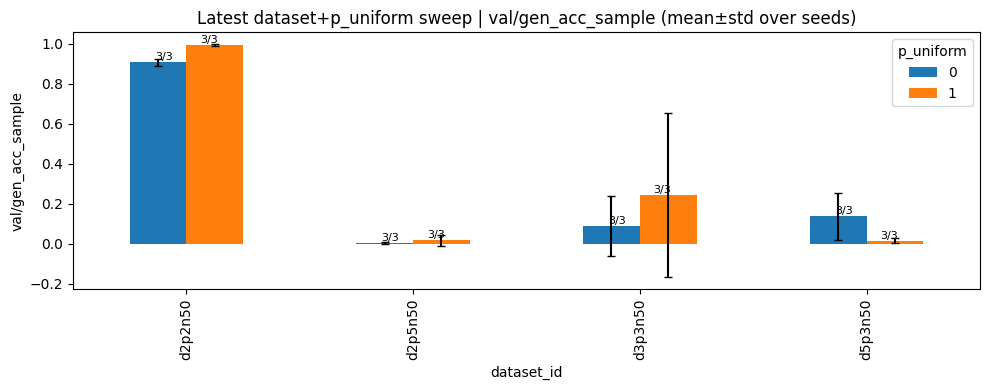

In [3]:
# Cell 3: plotting + usage
import matplotlib.pyplot as plt

def plot_dataset_pu_metric(agg_long: pd.DataFrame, metric: str, title_prefix="Latest dataset+p_uniform sweep"):
    d = agg_long[agg_long["metric"] == metric].copy()
    if d.empty:
        raise ValueError(f"No rows for metric={metric}")

    mean_pivot = d.pivot(index="dataset_id", columns="p_uniform", values="mean")
    std_pivot = d.pivot(index="dataset_id", columns="p_uniform", values="std")
    nvalid_pivot = d.pivot(index="dataset_id", columns="p_uniform", values="n_valid")
    nexp_pivot = d.pivot(index="dataset_id", columns="p_uniform", values="n_expected")

    ax = mean_pivot.plot(kind="bar", yerr=std_pivot, capsize=3, figsize=(10, 4))
    ax.set_title(f"{title_prefix} | {metric} (mean±std over seeds)")
    ax.set_xlabel("dataset_id")
    ax.set_ylabel(metric)
    ax.legend(title="p_uniform")

    # annotate n_valid / n_expected
    for i, dataset_id in enumerate(mean_pivot.index):
        for j, pu in enumerate(mean_pivot.columns):
            y = mean_pivot.loc[dataset_id, pu]
            if pd.isna(y):
                continue
            nv = int(nvalid_pivot.loc[dataset_id, pu])
            ne = int(nexp_pivot.loc[dataset_id, pu])
            ax.text(i + (j - 0.5) * 0.2, y, f"{nv}/{ne}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    return ax

# ---- usage ----
api = wandb.Api()
project = "laz4rz/star_graph_gidd_pu_seed_sweep_all_datasets"

df_runs = fetch_latest_dataset_pu_seed_runs(api, project)
metrics = ["val/gen_acc_sample", "val/gen_acc_token", "val/nll", "val/bpd"]

agg_long, agg_wide, diag = aggregate_seed_sweep(df_runs, metrics, expected_seeds=(1,2,3))

display(agg_wide)  # quick compare table

# signalize dropped/missing seeds clearly
problems = diag[diag["status"] != "ok"]
if problems.empty:
    print("All dataset_id x p_uniform x metric groups have full seed coverage and no NaNs.")
else:
    print("Incomplete groups detected (NaNs/missing seeds):")
    display(problems[["dataset_id", "p_uniform", "metric", "valid_seeds", "nan_seeds", "missing_seeds", "states_by_seed"]])

# plot one metric
plot_dataset_pu_metric(agg_long, metric="val/gen_acc_sample")
plt.show()


,metric,dataset_id,p_uniform,step,mean,std,n_valid
0,val/bpd,d2p2n50,0,499.0,0.170319,0.016808,3
1,val/bpd,d2p2n50,0,999.0,0.109829,0.000831,3
2,val/bpd,d2p2n50,0,1499.0,0.101277,0.002496,3
3,val/bpd,d2p2n50,0,1999.0,0.096596,0.002062,3
4,val/bpd,d2p2n50,0,2499.0,0.094266,0.001771,3


p_uniform,metric,dataset_id,step,p0_mean,p1_mean,delta_mean
0,val/bpd,d2p2n50,499.0,0.170319,0.236069,0.065750
1,val/bpd,d2p2n50,999.0,0.109829,0.189760,0.079931
2,val/bpd,d2p2n50,1499.0,0.101277,0.165465,0.064188
3,val/bpd,d2p2n50,1999.0,0.096596,0.158493,0.061897
4,val/bpd,d2p2n50,2499.0,0.094266,0.152004,0.057738


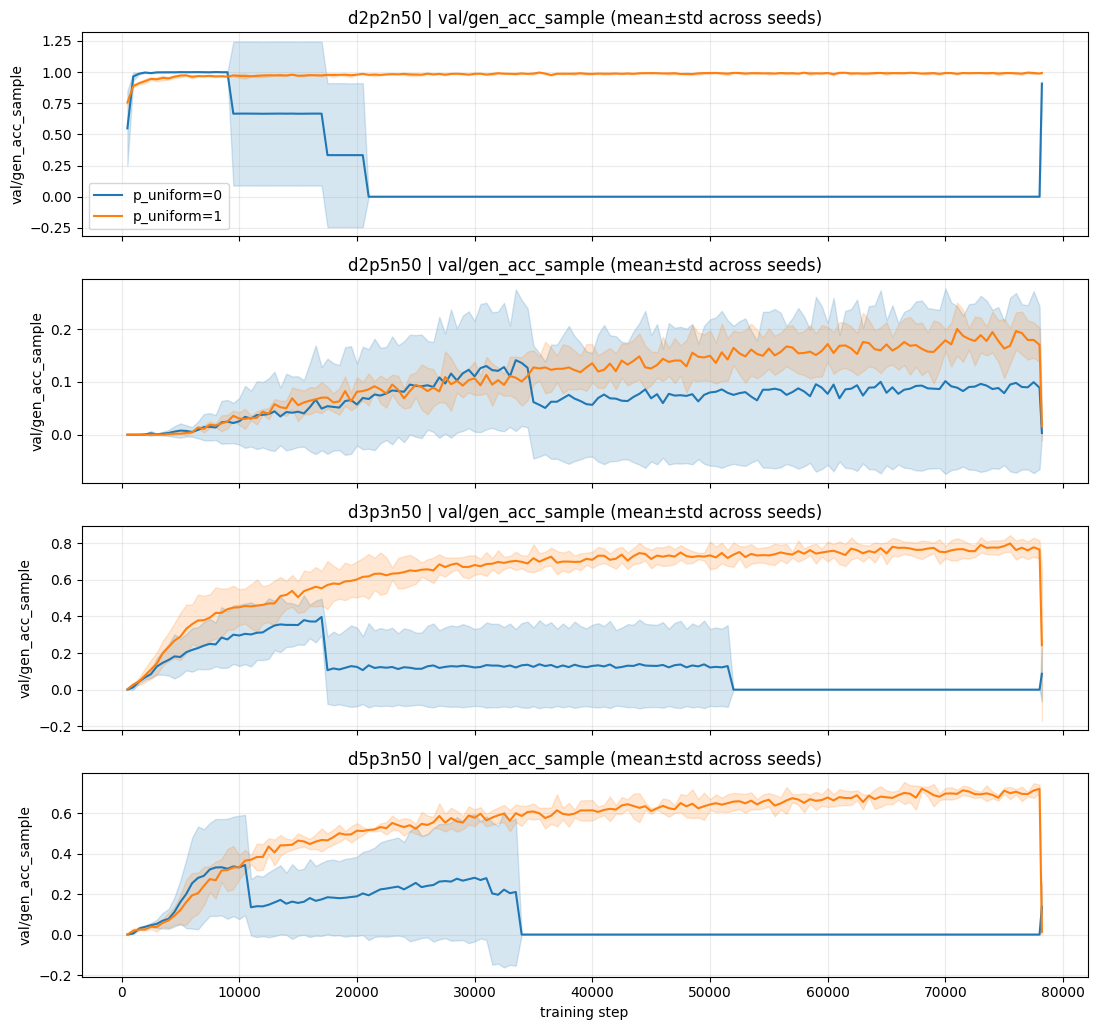

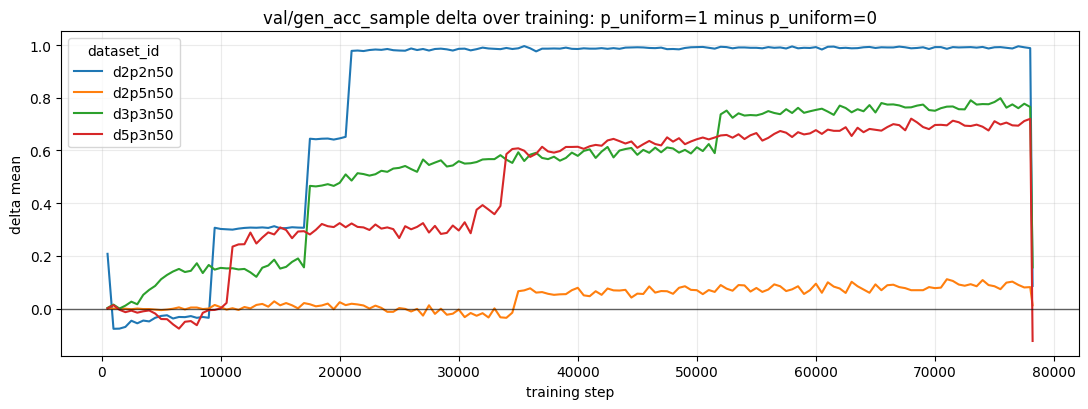

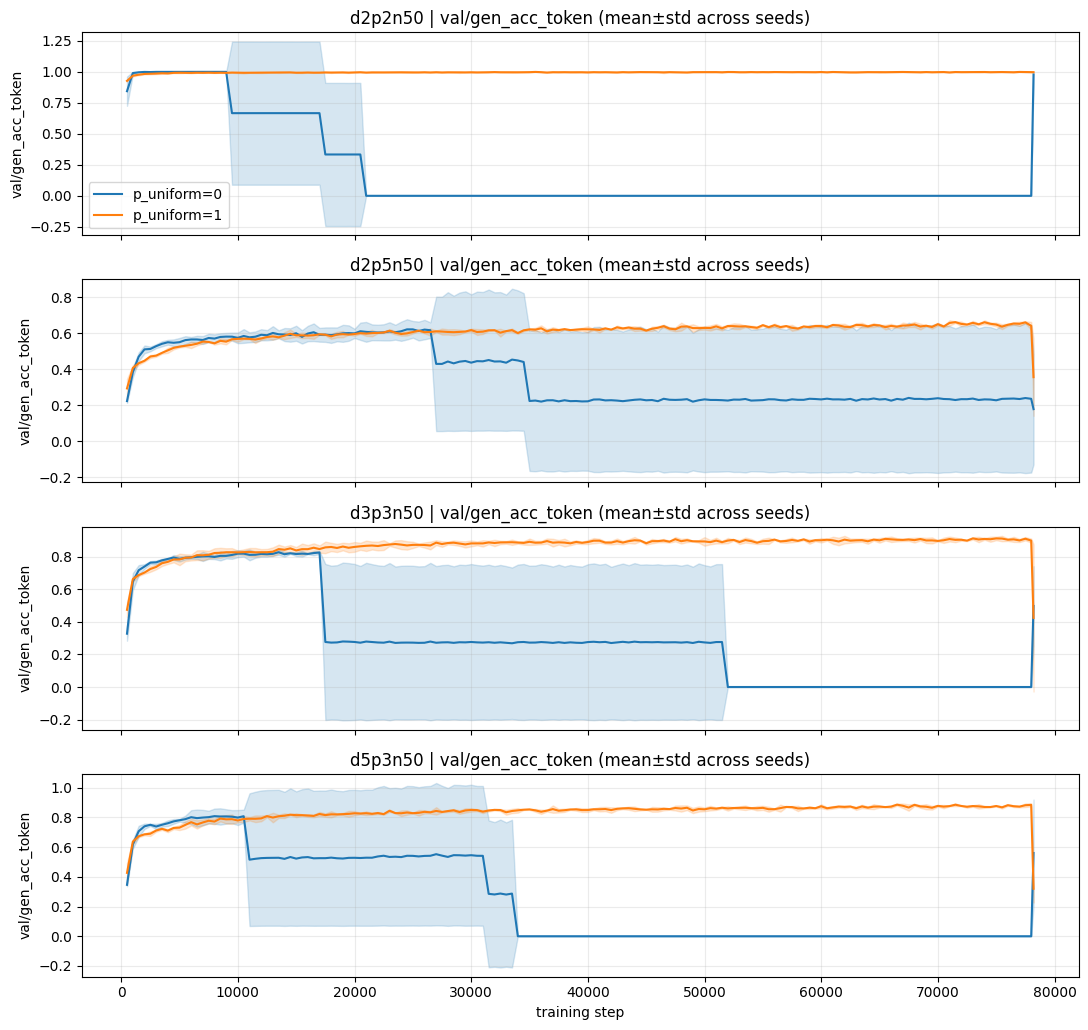

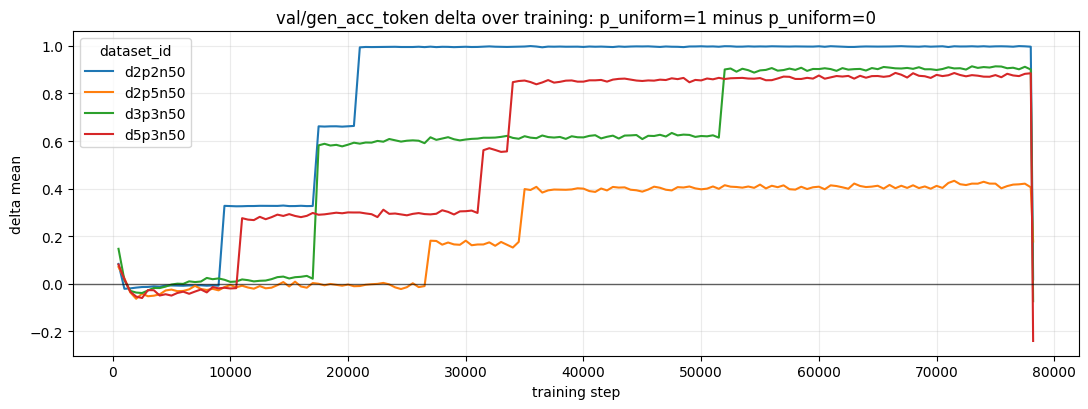

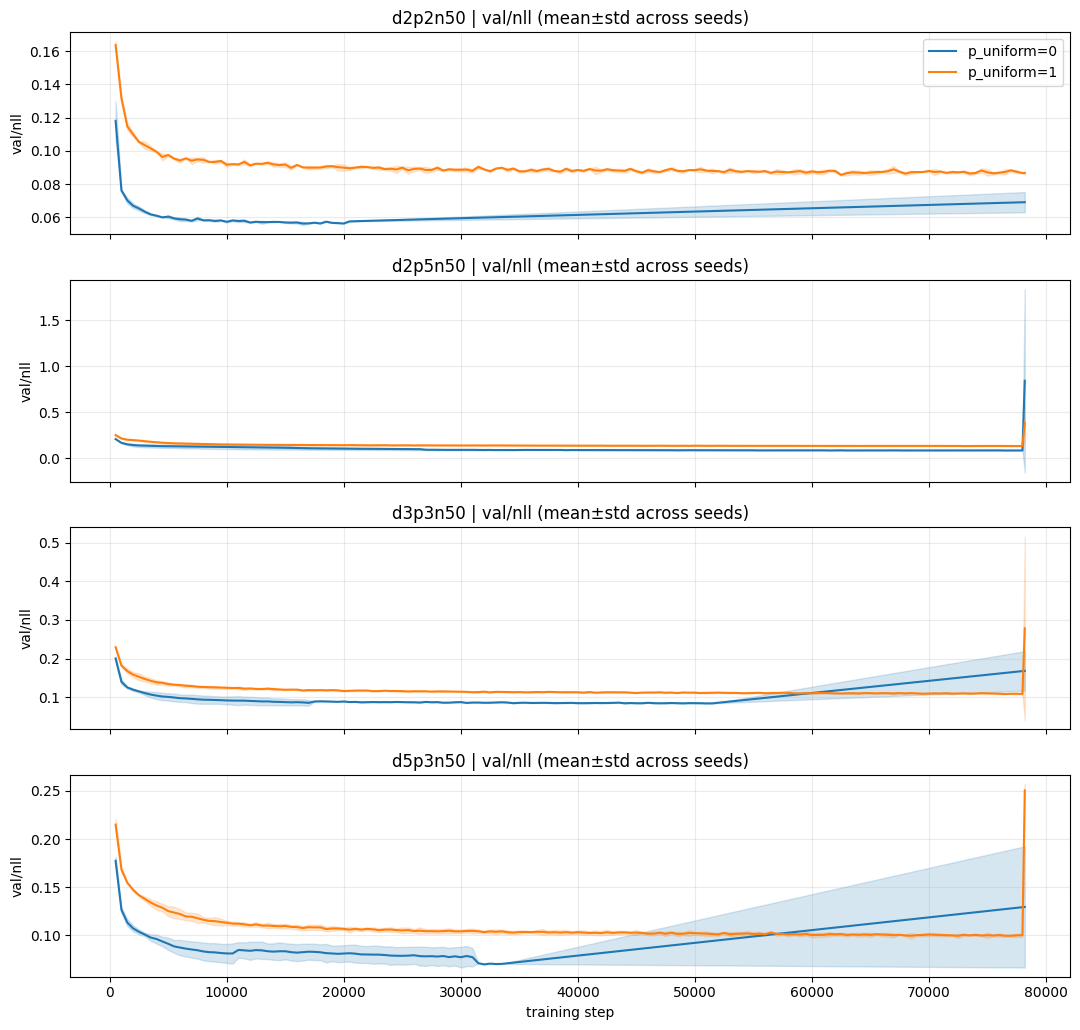

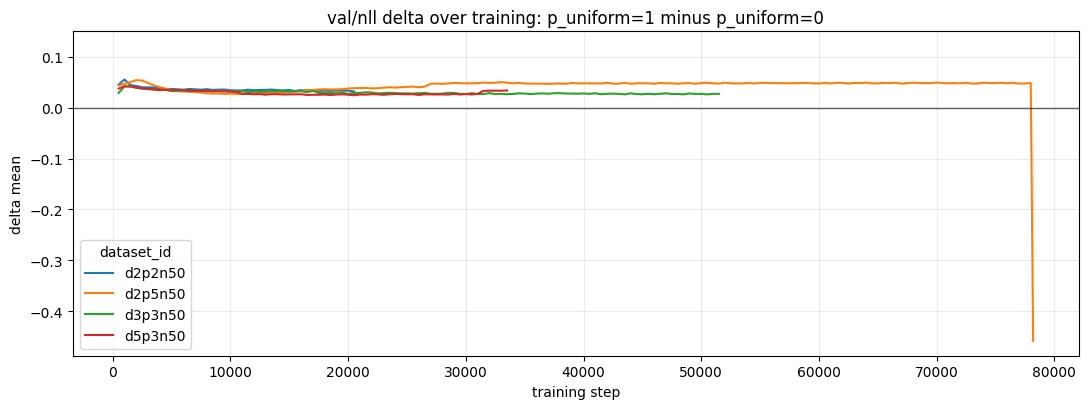

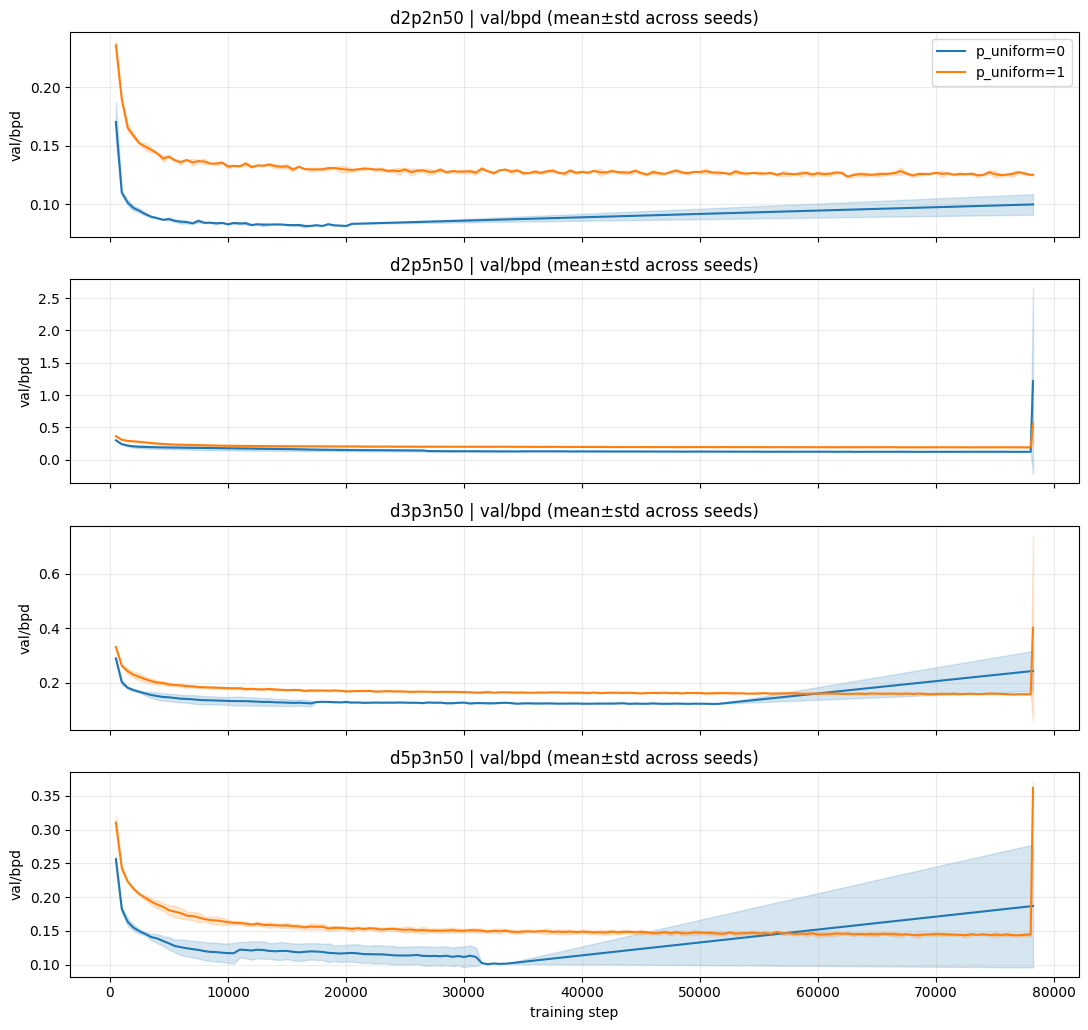

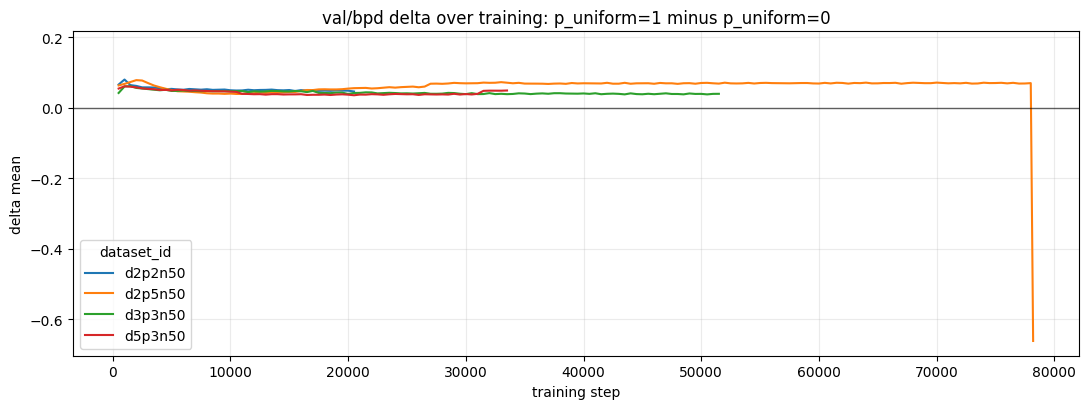

In [4]:
# Cell 4: trajectories across training (seed-averaged) + p_uniform deltas

def _pick_step(row: dict, step_keys=("trainer/global_step", "_step", "global_step")):
    for k in step_keys:
        v = row.get(k)
        if v is None:
            continue
        try:
            fv = float(v)
        except Exception:
            continue
        if pd.isna(fv):
            continue
        return fv
    return np.nan


def _to_float_or_nan(v):
    try:
        fv = float(v)
    except Exception:
        return np.nan
    return fv if not pd.isna(fv) else np.nan


def _extract_metric_points(run, metric: str, step_keys=("trainer/global_step", "_step", "global_step")):
    # scan_history(keys=...) can require all keys to be present, so try narrow queries first.
    query_key_sets = [[metric, sk] for sk in step_keys] + [[metric]]

    for keys in query_key_sets:
        points = []
        try:
            it = run.scan_history(keys=keys)
        except Exception:
            continue

        for h in it:
            step = _pick_step(h, step_keys=step_keys)
            if pd.isna(step):
                continue
            val = _to_float_or_nan(h.get(metric, np.nan))
            if pd.isna(val):
                continue
            points.append((float(step), float(val)))

        if points:
            # Keep latest value per step in case of duplicates.
            by_step = {}
            for s, v in points:
                by_step[s] = v
            return sorted(by_step.items(), key=lambda x: x[0]), keys

    return [], None


def fetch_metric_trajectories(
    api,
    project: str,
    df_runs: pd.DataFrame,
    metrics: list[str],
    step_keys=("trainer/global_step", "_step", "global_step"),
):
    metrics = list(metrics)
    rows = []

    runs_total = 0
    run_metric_hits = 0

    for _, rec in df_runs.iterrows():
        runs_total += 1
        run = api.run(f"{project}/{rec['run_id']}")

        for m in metrics:
            points, used_keys = _extract_metric_points(run, m, step_keys=step_keys)
            if not points:
                continue

            run_metric_hits += 1
            for step, val in points:
                rows.append({
                    "dataset_id": rec["dataset_id"],
                    "p_uniform": int(rec["p_uniform"]),
                    "seed": int(rec["seed"]),
                    "run_id": rec["run_id"],
                    "metric": m,
                    "step": float(step),
                    "value": float(val),
                    "history_keys": ",".join(used_keys) if used_keys is not None else "",
                })

    out = pd.DataFrame(rows)
    if out.empty:
        raise RuntimeError(
            "No trajectory history found for requested metrics. "
            f"runs_total={runs_total}, run_metric_hits={run_metric_hits}, "
            f"metrics={metrics}, step_keys={step_keys}"
        )

    return out.sort_values(["metric", "dataset_id", "p_uniform", "seed", "step"]).reset_index(drop=True)


def aggregate_seed_trajectories(traj_long: pd.DataFrame):
    agg = (
        traj_long
        .groupby(["metric", "dataset_id", "p_uniform", "step"], as_index=False)
        .agg(
            mean=("value", "mean"),
            std=("value", "std"),
            n_valid=("value", "count"),
        )
        .sort_values(["metric", "dataset_id", "p_uniform", "step"])
        .reset_index(drop=True)
    )
    agg["std"] = agg["std"].fillna(0.0)
    return agg


def build_p_uniform_diff(agg_traj: pd.DataFrame, p0=0, p1=1):
    work = agg_traj[agg_traj["p_uniform"].isin([p0, p1])].copy()
    if work.empty:
        return pd.DataFrame(columns=["metric", "dataset_id", "step", "delta_mean", "p0_mean", "p1_mean"])

    wide = (
        work
        .pivot_table(
            index=["metric", "dataset_id", "step"],
            columns="p_uniform",
            values="mean",
            aggfunc="first",
        )
        .reset_index()
    )

    if p0 not in wide.columns or p1 not in wide.columns:
        return pd.DataFrame(columns=["metric", "dataset_id", "step", "delta_mean", "p0_mean", "p1_mean"])

    out = wide.rename(columns={p0: "p0_mean", p1: "p1_mean"})
    out["delta_mean"] = out["p1_mean"] - out["p0_mean"]
    return out.sort_values(["metric", "dataset_id", "step"]).reset_index(drop=True)


def plot_seed_avg_trajectories(agg_traj: pd.DataFrame, metric: str, datasets=None):
    d = agg_traj[agg_traj["metric"] == metric].copy()
    if d.empty:
        raise ValueError(f"No trajectory rows for metric={metric}")

    dataset_list = sorted(d["dataset_id"].unique()) if datasets is None else list(datasets)
    n = len(dataset_list)
    fig, axes = plt.subplots(n, 1, figsize=(11, max(3.0, 2.6 * n)), sharex=True)
    if n == 1:
        axes = [axes]

    colors = {0: "tab:blue", 1: "tab:orange"}

    for ax, dataset_id in zip(axes, dataset_list):
        dd = d[d["dataset_id"] == dataset_id]

        for pu in sorted(dd["p_uniform"].unique()):
            s = dd[dd["p_uniform"] == pu].sort_values("step")
            if s.empty:
                continue

            c = colors.get(int(pu), None)
            ax.plot(s["step"], s["mean"], label=f"p_uniform={int(pu)}", color=c)
            if (s["n_valid"] > 1).any():
                ax.fill_between(
                    s["step"],
                    s["mean"] - s["std"],
                    s["mean"] + s["std"],
                    alpha=0.18,
                    color=c,
                )

        ax.set_title(f"{dataset_id} | {metric} (mean±std across seeds)")
        ax.set_ylabel(metric)
        ax.grid(alpha=0.25)

    axes[-1].set_xlabel("training step")
    axes[0].legend(loc="best")
    plt.tight_layout()
    return fig, axes


def plot_p_uniform_delta(delta_df: pd.DataFrame, metric: str, datasets=None):
    d = delta_df[delta_df["metric"] == metric].copy()
    if d.empty:
        raise ValueError(f"No p_uniform delta rows for metric={metric}")

    dataset_list = sorted(d["dataset_id"].unique()) if datasets is None else list(datasets)

    fig, ax = plt.subplots(figsize=(11, 4.2))
    for dataset_id in dataset_list:
        s = d[d["dataset_id"] == dataset_id].sort_values("step")
        if s.empty:
            continue
        ax.plot(s["step"], s["delta_mean"], label=dataset_id)

    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_title(f"{metric} delta over training: p_uniform=1 minus p_uniform=0")
    ax.set_xlabel("training step")
    ax.set_ylabel("delta mean")
    ax.grid(alpha=0.25)
    ax.legend(title="dataset_id", loc="best")
    plt.tight_layout()
    return fig, ax


# ---- usage ----
trajectory_metrics = ["val/gen_acc_sample", "val/gen_acc_token", "val/nll", "val/bpd"]

traj_long = fetch_metric_trajectories(api, project, df_runs, metrics=trajectory_metrics)
traj_agg = aggregate_seed_trajectories(traj_long)
traj_delta = build_p_uniform_diff(traj_agg, p0=0, p1=1)

display(traj_agg.head())
display(traj_delta.head())

for m in trajectory_metrics:
    plot_seed_avg_trajectories(traj_agg, metric=m)
    plt.show()

    plot_p_uniform_delta(traj_delta, metric=m)
    plt.show()

